# Week 2 - Classical Prep ReAct Graph with Memory and Interrupt

1주차 클래식 공연 예습 ReAct 그래프를 같은 도메인으로 재사용하고, week2 요구사항인 checkpointer, thread_id 분리, interrupt 실행제어, 맥락 질문 결과를 정리합니다.

- 기본 그래프: `graph = builder.compile(checkpointer=memory)`
- 실행제어 그래프: `graph_with_interrupt = builder.compile(checkpointer=interrupt_memory, interrupt_before=["tools"])`
- interrupt 시나리오: 공연 상세 내용이 긴 포스터 이미지에만 있을 때, 이미지/포스터 정보 추출 도구 실행 전 사용자의 승인을 받습니다.


In [28]:
from pathlib import Path
import sys

cwd = Path.cwd()
candidates = [cwd, cwd / "assignments" / "daexvk" / "week2", cwd / "week2"]
target_dir = next(path for path in candidates if (path / "graph.py").exists())
sys.path.insert(0, str(target_dir.resolve()))

print("target_dir:", target_dir.resolve())

target_dir: /Users/nozerose/Documents/GitHub/rag-agent-study/assignments/daexvk/week2


## Graph and Checkpointer

week1의 `agent -> tools -> agent` ReAct 구조를 그대로 유지하고, week2에서는 compile 단계에 `InMemorySaver` checkpointer를 결합했습니다. `thread_id`가 같으면 같은 체크포인트 이력을 이어 쓰고, 다르면 별도의 대화로 저장됩니다.


In [29]:
import importlib
import tools as tools_module
import graph as graph_module

# 노트북 커널이 이전 graph/tools 모듈을 캐시하는 경우가 있어 최신 파일을 강제로 다시 로드합니다.
importlib.reload(tools_module)
importlib.reload(graph_module)

from graph import graph, graph_with_interrupt, memory, interrupt_memory

print("graph:", type(graph).__name__)
print("checkpointer:", type(memory).__name__)
print("interrupt graph:", type(graph_with_interrupt).__name__)
print("interrupt checkpointer:", type(interrupt_memory).__name__)

graph: CompiledStateGraph
checkpointer: InMemorySaver
interrupt graph: CompiledStateGraph
interrupt checkpointer: InMemorySaver


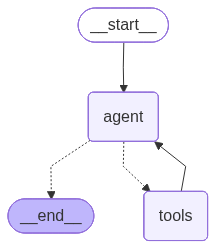

Graph image saved to: /Users/nozerose/Documents/GitHub/rag-agent-study/assignments/daexvk/week2/graph.png


In [30]:
from pathlib import Path
from IPython.display import Image, Markdown, display

output_dir = Path(".")
png_path = output_dir / "graph.png"
mermaid_path = output_dir / "graph.mmd"

try:
    png = graph.get_graph().draw_mermaid_png()
    png_path.write_bytes(png)
    display(Image(png))
    print(f"Graph image saved to: {png_path.resolve()}")
except Exception as exc:
    print("PNG rendering failed, saving Mermaid instead:", exc)
    mermaid = graph.get_graph().draw_mermaid()
    mermaid_path.write_text(mermaid, encoding="utf-8")
#     display(Markdown("```mermaid
# " + mermaid + "
# ```"))
#     print(f"Mermaid graph saved to: {mermaid_path.resolve()}")

## Helpers

In [31]:
from langchain_core.messages import HumanMessage


def invoke_with_thread(question: str, thread_id: str):
    config = {"recursion_limit": 20, "configurable": {"thread_id": thread_id}}
    result = graph.invoke(
        {"messages": [HumanMessage(content=question)], "used_tools": [], "final_answer": None},
        config=config,
    )
    return result, config


def _answer_get(answer, key, default=None):
    if isinstance(answer, dict):
        return answer.get(key, default)
    return getattr(answer, key, default)


def summarize_result(label: str, question: str, result: dict):
    answer = result.get("final_answer")
    latest = result["messages"][-1].content
    print(f"[{label}]")
    print("Q:", question)
    print("used_tools:", result.get("used_tools", []))
    if answer:
        print("work:", _answer_get(answer, "work_title"))
        print("summary:", _answer_get(answer, "summary", "")[:220].replace("\n", " "))
    else:
        print(latest[:300])
    print("messages:", len(result.get("messages", [])))
    print("latest_message_length:", len(latest))


## Context Questions

맥락 질문은 3개 이상 남겼습니다.

1. 첫 질문: 말러 5번 전체 예습
2. 같은 thread의 두 번째 질문: 직전 답변 맥락을 이어 4악장 아다지에토만 질문
3. 다른 thread의 같은 질문: 같은 내용을 새 thread에서 질문해 대화가 분리되는지 확인


In [ ]:
# 맥락 이용 질문 1
question = 'https://www.bsgangseo.go.kr/nac/portal/concertSchedule/list.do?mid=0101000000&token=1780758062439 여기에서 공연을 추천해줘'
result_same_1, config_same = invoke_with_thread(question, "thread_1")
summarize_result("same thread / first question", question, result_same_1)

[same thread / first question]
Q: https://www.bsgangseo.go.kr/nac/portal/concertSchedule/list.do?mid=0101000000&token=1780758062439 여기에서 공연을 추천해줘
used_tools: ['fetch_concert_page']
work: 공연일정 중 초보자에게 추천할 만한 클래식 공연
summary: 이 페이지에는 여러 공연이 함께 올라와 있습니다. 초보자라면 친숙한 곡이 나올 가능성이 높고 설명 제목도 쉬운 <오케스트라의 분위기 메이커들>, <현악기의 진짜 매력>, 그리고 부담 없이 듣기 좋은 [마티네콘서트] 성악 앙상블 시리즈 Ⅲ를 먼저 추천합니다. 대형곡을 원하면 NAC@ NAFO시리즈 - 교향곡 속의 합창도 좋지만, 처음이라면 제목만 봐도 접근성이 높은 프로그램부터 고르는 편이 편
messages: 4
latest_message_length: 1971


In [34]:
question = '방금 추천 해준 공연 이름이 뭐였지 ? '
result_same_2, config_same = invoke_with_thread(question, "thread_1")
summarize_result("same thread / second question", question, result_same_2)

[same thread / second question]
Q: 방금 추천 해준 공연 이름이 뭐였지 ? 
used_tools: ['fetch_concert_page']
work: 공연일정 중 초보자에게 추천할 만한 클래식 공연
summary: 방금 추천한 건 낙동아트센터 공연일정에 있는 여러 클래식 공연이었어요. 그중 초보자에게는 <현악기의 진짜 매력>, <오케스트라의 분위기 메이커들>, 그리고 [마티네콘서트] 성악 앙상블 시리즈 Ⅲ 오네스토 앙상블의 '힐링 뮤직브런치'를 먼저 추천했습니다.
messages: 6
latest_message_length: 1150


In [35]:
question = '너가 방금 추천해준 공연 이름이 뭐였더라 ?'
result_new, config_new = invoke_with_thread(question, "thread_2")
summarize_result("different thread / same question", question, result_new)

[different thread / same question]
Q: 너가 방금 추천해준 공연 이름이 뭐였더라 ?
used_tools: []
work: 알 수 없음
summary: 직전에 추천한 공연 정보를 현재 대화에서 확인할 수 없어서 공연 이름을 특정할 수 없습니다.
messages: 2
latest_message_length: 668


In [39]:
# 맥락 이용 질문 2
question = '우리나라 클래식 연주자 중에서 유명한 사람이 누가 있어 ?'
result_3, config_3 = invoke_with_thread(question, "thread_3")
summarize_result("same thread / first question", question, result_3)

[same thread / first question]
Q: 우리나라 클래식 연주자 중에서 유명한 사람이 누가 있어 ?
used_tools: []
work: 한국의 유명 클래식 연주자
summary: 질문은 특정 공연 예습보다는 한국의 유명 클래식 연주자 소개에 가깝습니다. 대표적인 연주자들을 악기별로 간단히 정리해드리면, 세계 무대에서 활약한 바이올리니스트 정경화·사라 장, 첼리스트 장한나, 피아니스트 조성진·손열음, 지휘자 정명훈, 성악가 조수미 등이 널리 알려져 있습니다.
messages: 2
latest_message_length: 876


In [40]:
question = '방금 추천해준 피아니스트 이름이 뭐지 ?'
result_4, config_3 = invoke_with_thread(question, "thread_3")
summarize_result("same thread / first question", question, result_4)

[same thread / first question]
Q: 방금 추천해준 피아니스트 이름이 뭐지 ?
used_tools: []
work: 피아니스트 이름 확인
summary: 직전 답변에서 한국의 유명 클래식 연주자로 피아니스트 조성진, 손열음을 언급했습니다. 질문하신 '방금 추천해준 피아니스트'는 이 두 사람 중 하나일 가능성이 높습니다.
messages: 4
latest_message_length: 639


In [42]:
# 맥락 이용 질문 3
question = '첼로 연주자 중에 유튜브 하는 사람 추천해줘 한국 사람으로'
result_5, config_4 = invoke_with_thread(question, "thread_4")
summarize_result("same thread / first question", question, result_5)

[same thread / first question]
Q: 첼로 연주자 중에 유튜브 하는 사람 추천해줘 한국 사람으로
used_tools: ['retrieve_preview_keywords']
work: 한국인 첼리스트 유튜브 채널 추천
summary: 한국인 첼리스트 중 유튜브 활동을 하는 사람을 찾고 계시네요. 다만 현재 대화만으로는 실시간으로 채널의 ‘활성도’와 최신 운영 여부를 확정하기 어려워서, 안전하게는 특정 스타일별로 직접 확인하는 방식이 좋습니다. 원하시면 제가 한국인 첼리스트 유튜브 채널을 연주형/교육형/일상형으로 나눠 추천해드릴 수 있습니다.
messages: 8
latest_message_length: 1077


In [43]:
question = '연주형으로 추천해줘'
result_6, config_4 = invoke_with_thread(question, "thread_4")
summarize_result("same thread / first question", question, result_6)

[same thread / first question]
Q: 연주형으로 추천해줘
used_tools: ['retrieve_preview_keywords']
work: 한국인 첼리스트 유튜브 채널 추천(연주형)
summary: 연주형으로 활동하는 한국인 첼리스트를 찾고 계시네요. 실시간 채널 활성도는 변동될 수 있어서, 지금 시점에서 특정 채널의 최신 업로드 여부를 단정하긴 어렵습니다. 대신, 연주 영상 위주로 찾을 때는 ‘공식 채널/콘서트 실황/리사이틀 영상/Shorts’가 꾸준한 채널을 고르는 게 좋습니다.
messages: 10
latest_message_length: 1131


## State History Metrics for PR

PR에 첨부할 `get_state_history()` 요약입니다. 같은 thread는 첫 질문과 두 번째 질문을 이어 받아 스냅샷과 메시지가 더 많고, 다른 thread는 같은 질문이라도 별도 대화로 시작합니다.


In [36]:
def print_state_history_summary(label: str, config: dict):
    history = list(graph.get_state_history(config))
    latest = history[0]
    messages = latest.values.get("messages", [])
    latest_msg = messages[-1].content if messages else ""
    print(
        f"{label}: snapshots={len(history)}, "
        f"latest_messages={len(messages)}, "
        f"latest_message_length={len(latest_msg)}"
    )


print_state_history_summary("thread_1", config_same)
print_state_history_summary("thread_2", config_new)

thread_1: snapshots=8, latest_messages=6, latest_message_length=1150
thread_2: snapshots=3, latest_messages=2, latest_message_length=668


## Interrupt Pattern: Poster OCR Approval

요즘 공연 상세 페이지는 텍스트 대신 긴 포스터 이미지에 프로그램/연주자/시간이 들어있는 경우가 많습니다. 이 경우 `graph_with_interrupt`를 사용해 도구 노드 실행 직전에 멈추고, 사용자가 포스터 OCR을 승인한 뒤 `stream(None, config, ...)`로 이어서 실행합니다.

`extract_poster_image_text`는 페이지의 이미지 후보와 주변 텍스트를 함께 참고하고, 사용자에게는 raw OCR 로그가 아니라 정리된 공연 정보만 반환합니다.


In [37]:
from graph import graph_with_interrupt

poster_config = {"recursion_limit": 12, "configurable": {"thread_id": "poster-approval-demo"}}
poster_question = (
    "본문 텍스트 추출은 이미 실패했어. 이 공연 링크의 세부 정보는 긴 포스터 이미지 안에만 있으니 "
    "fetch_concert_page 대신 extract_poster_image_text 도구로 포스터 이미지를 승인 후 읽어서 공연 정보를 정리해줘. "
    "URL: https://classicbusan.busan.go.kr/product/performance/253216?q=OTdhYjcwN2I0Y2ZiNGQ3NWJmZjg3ZDFiZjFmZjFjMDc%3d"
)

for event in graph_with_interrupt.stream(
    {"messages": [HumanMessage(content=poster_question)], "used_tools": [], "final_answer": None},
    config=poster_config,
    stream_mode="updates",
):
    print(event.keys())

pending_state = graph_with_interrupt.get_state(poster_config)
print("next:", pending_state.next)
print("approval_target_tool_calls:", pending_state.values["messages"][-1].tool_calls)


dict_keys(['agent'])
dict_keys(['__interrupt__'])
next: ('tools',)
approval_target_tool_calls: [{'name': 'extract_poster_image_text', 'args': {'url': 'https://classicbusan.busan.go.kr/product/performance/253216?q=OTdhYjcwN2I0Y2ZiNGQ3NWJmZjg3ZDFiZjFmZjFjMDc%3d'}, 'id': 'call_o6MOuThQgNOmzQ5zPVFaXrJC', 'type': 'tool_call'}]


In [ ]:
# 사용자가 포스터 OCR을 승인했다고 가정하면 None 입력으로 같은 thread를 재개합니다.
# 내부 실행 로그는 숨기고, 사용자가 최종적으로 볼 포스터 정보 정리만 출력합니다.
for _ in graph_with_interrupt.stream(None, config=poster_config, stream_mode="updates"):
    pass

resumed_state = graph_with_interrupt.get_state(poster_config)
tool_messages = [message for message in resumed_state.values["messages"] if getattr(message, "type", None) == "tool"]

print("--- POSTER INFO SUMMARY ---")
if tool_messages:
    print(tool_messages[-1].content[:2500])
else:
    print("포스터 OCR 결과를 찾지 못했습니다.")


--- POSTER INFO SUMMARY ---
[포스터 기반 공연 정보 정리]
**공연명** 
조성진 체임버 콘서트 (Seong-Jin Cho Chamber Concert)

**일시** 
2026. 07. 17. fri 17:00

**장소** 
부산콘서트홀

**출연진** 
- 조성진 
- 포스터에 피아노 없이 각기 악기를 든 실내악 출연진 사진이 함께 보이지만, 이름 표기는 포스터에서 선명하게 확인되지 않음

**프로그램/곡명** 
- 포스터 이미지에는 곡명이 보이지 않음 
- 프로그램 상세는 주변 페이지 텍스트에도 노출되지 않음

**예습에 필요한 핵심 요약** 
- 조성진이 중심이 되는 실내악 공연으로 보임 
- 부산콘서트홀에서 열리는 클래식 공연 상세 페이지의 포스터이며, “WORLD STAR SERIES” 표기가 있음 
- 예매 정보로 보이는 좌석 등급 및 가격이 포스터에 함께 표기됨: R 180,000 / S 160,000 / A 140,000 / B 120,000 / C 80,000 / 학생석 10,000

**불확실한 정보** 
- 정확한 편성(함께 연주하는 다른 출연진의 실명) 
- 정확한 프로그램/곡목 
- 공연 시간 외 상세 러닝타임 
- 포스터 내 작은 사진들에 대한 출처/관계 설명

참고 이미지: https://classicbusan.busan.go.kr/Down/Rent/202605/e2ee0e93-35ce-4d73-86fd-4c208c43205e.jpg
참고: 포스터 이미지와 주변 페이지 텍스트를 함께 사용해 정리했습니다.


## Summary

- week1의 클래식 공연 예습 ReAct 그래프를 같은 도메인으로 재사용했습니다.
- `InMemorySaver` checkpointer를 `compile()`에 결합했습니다.
- 같은 `thread_id`의 두 번째 질문과 다른 `thread_id`의 같은 질문을 비교했습니다.
- `get_state_history()` 결과를 PR에 첨부할 수 있도록 정리했습니다.
- 실행제어 패턴으로 `interrupt_before=["tools"]`를 적용했습니다.
- 포스터 이미지에 공연 상세 정보가 들어있는 경우, 승인 후 비전 OCR을 수행하고 사용자에게는 정리된 공연 정보만 보여주도록 구성했습니다.
